In [19]:
%matplotlib inline
import os
import glob
import random
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from ultralytics import YOLO

In [20]:
# Cell 2: Load the Best Custom Weights (Auto-Discovery)
import os
import glob
from ultralytics import YOLO

# Automatically find all best.pt files in your runs directory
list_of_models = glob.glob('../runs/**/best.pt', recursive=True)

if not list_of_models:
    print("❌ Could not find any trained model files. Please check your runs folder.")
else:
    # Get the most recently modified model file
    latest_model_path = max(list_of_models, key=os.path.getctime)
    print(f"🔍 Found newest model at: {latest_model_path}")
    
    # Load the model into memory
    model = YOLO(latest_model_path)
    print("✅ Custom Brain Tumor Model loaded successfully!")

🔍 Found newest model at: ../runs/detect/models/tumor_detector-6/weights/best.pt
✅ Custom Brain Tumor Model loaded successfully!


In [21]:
# Cell 3: Standard Multi-Class Evaluation (mAP & Curves)
print("Running standard evaluation to generate PR Curves and Confusion Matrix...")

# We added 'plots=True' to FORCE YOLO to physically draw the matrix!
metrics = model.val(
    data='../data/raw/data.yaml', 
    split='test', 
    batch=4, 
    plots=True  # <-- THE MAGIC WORD
)

print("\n--- OFFICIAL YOLO METRICS (Multi-Class) ---")
print(f"Mean Average Precision (mAP50): {metrics.box.map50:.3f}")
print("Check your 'runs/detect/val' folder for the new PR_curve.png and Confusion Matrix!")

Running standard evaluation to generate PR Curves and Confusion Matrix...
Ultralytics 8.4.46 🚀 Python-3.10.20 torch-2.11.0+cu130 CUDA:0 (NVIDIA GeForce RTX 3050 Laptop GPU, 4096MiB)
YOLO26n summary (fused): 122 layers, 2,375,616 parameters, 0 gradients, 5.2 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 59.6±25.6 MB/s, size: 35.1 KB)
val: Scanning /home/dikshant/projects/brain-tumor-detection/data/raw/test/labels.cache... 246 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 246/246 33.3Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 62/62 18.2it/s 3.4s0.0s
                   all        246        250      0.935      0.927      0.941      0.596
                Glioma         80         84      0.942       0.94      0.966      0.713
            Meningioma         63         63      0.934      0.905      0.926       0.54
              No Tumor         49         49       0.97      0.939      0.957      0.6

🔍 Displaying newest matrix from: runs/detect/val-12/confusion_matrix.png


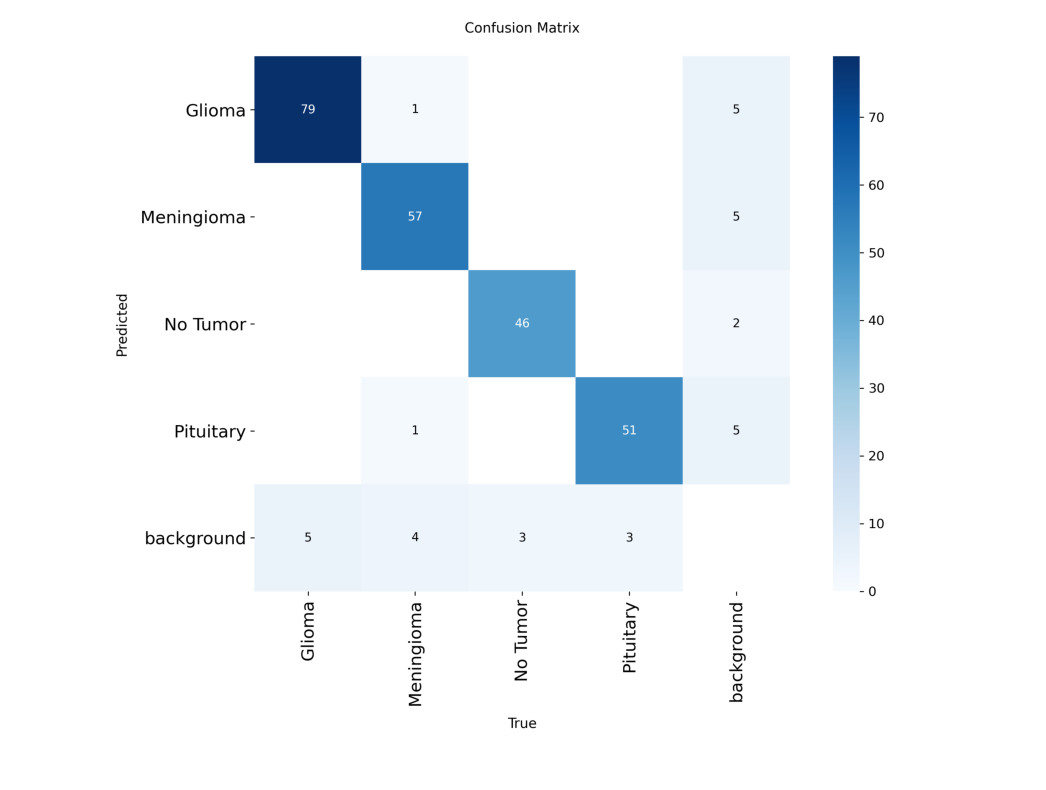

In [22]:
# Cell 4: Display the Official Confusion Matrix
%matplotlib inline
import os
import glob
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

# Search BOTH the local directory and the parent directory for the matrix
matrix_files = glob.glob('runs/**/confusion_matrix.png', recursive=True) + \
               glob.glob('../runs/**/confusion_matrix.png', recursive=True)

if not matrix_files:
    print("❌ Confusion matrix not found. Did Cell 3 finish running?")
else:
    # Get the most recently created matrix image
    latest_matrix = max(matrix_files, key=os.path.getctime)
    print(f"🔍 Displaying newest matrix from: {latest_matrix}")
    
    # Read and display the image beautifully
    img = mpimg.imread(latest_matrix)
    
    plt.figure(figsize=(12, 8)) 
    plt.imshow(img)
    plt.axis('off') 
    plt.tight_layout()
    plt.show()

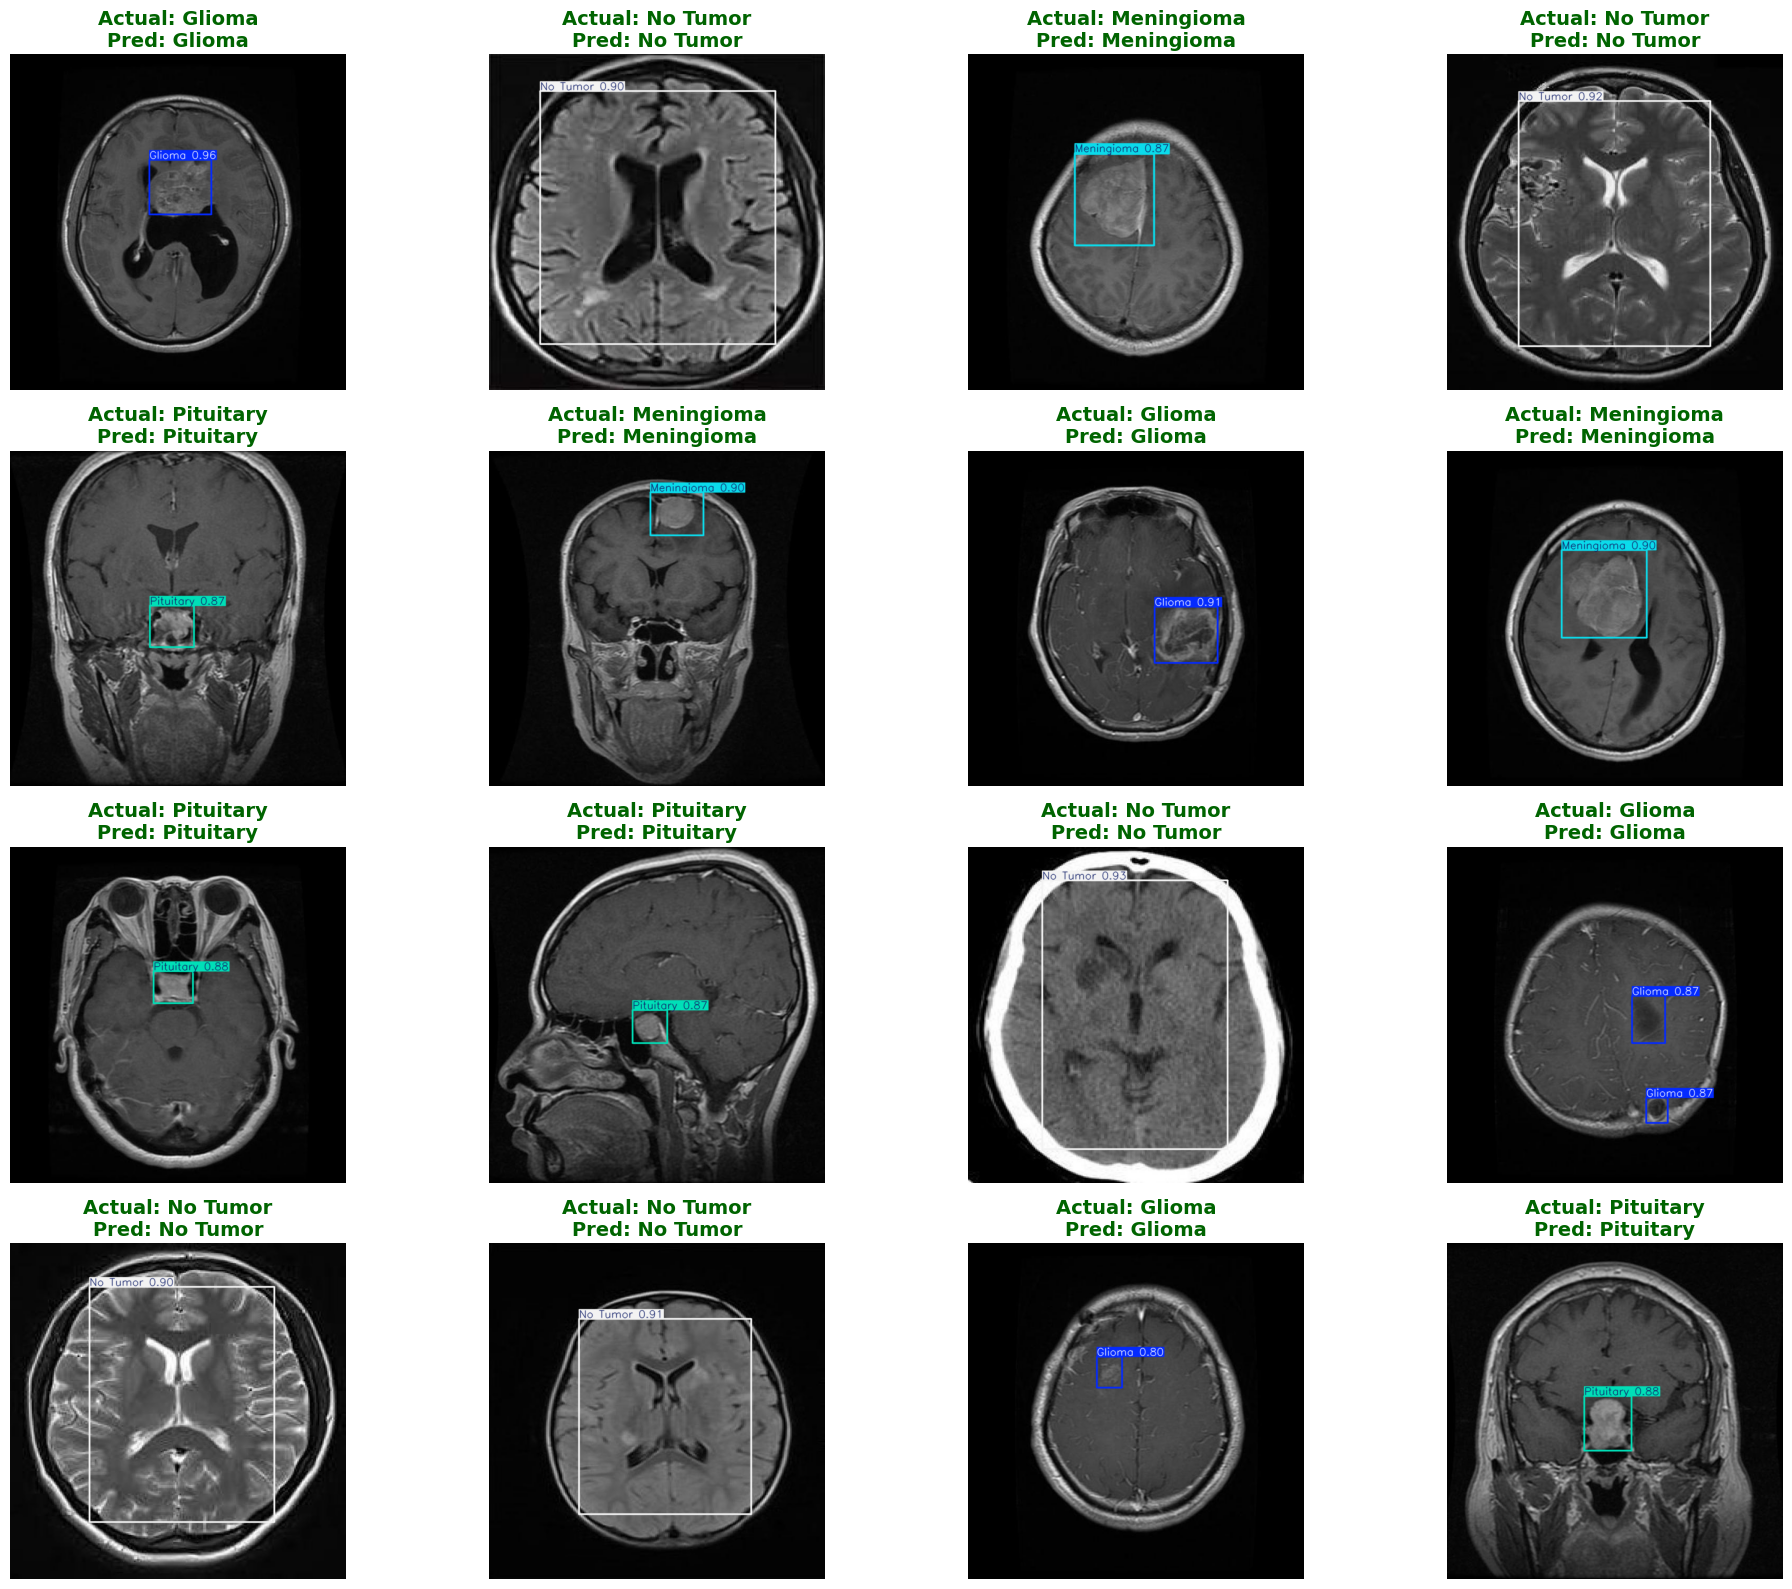

In [23]:
# Cell 5: Large Grid Visual Inference vs Ground Truth
%matplotlib inline 
import os
import glob
import random
import matplotlib.pyplot as plt

# Define directories
test_img_dir = '../data/raw/test/images'
test_label_dir = '../data/raw/test/labels'

# Get 12 random images for a 3x4 grid
test_images = glob.glob(os.path.join(test_img_dir, '*.jpg'))
num_images = 16
selected_images = random.sample(test_images, num_images)

# Run model prediction
results = model.predict(source=selected_images, conf=0.05, verbose=False)

# Create a 3x4 grid of subplots
fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten() 

for i, r in enumerate(results):
    # 1. --- GET THE TRUE LABEL ---
    original_img_path = selected_images[i] 
    
    base_name = os.path.splitext(os.path.basename(original_img_path))[0]
    label_path = os.path.join(test_label_dir, f"{base_name}.txt")
    
    true_labels = []
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            lines = f.readlines()
            for line in lines:
                class_id = int(line.split()[0]) 
                # THE FIX: Ask the model for the name directly!
                true_labels.append(model.names[class_id])
                
    # Format true text
    true_text = "Clean / No Tumor" if not true_labels else ", ".join(set(true_labels))

    # 2. --- GET THE PREDICTED LABEL IN TEXT ---
    pred_classes = r.boxes.cls.cpu().numpy()
    pred_labels = [r.names[int(cls)] for cls in pred_classes]
    
    # Format predicted text
    pred_text = "Clean / No Tumor" if not pred_labels else ", ".join(set(pred_labels))

    # 3. --- DRAW THE PREDICTION ON THE IMAGE ---
    img_bgr = r.plot() 
    img_rgb = img_bgr[:, :, ::-1] 
    
    axes[i].imshow(img_rgb)
    axes[i].axis('off')
    
    # 4. --- FORMAT THE TITLE WITH COLOR CODING ---
    is_correct = set(true_labels) == set(pred_labels)
    title_color = 'darkgreen' if is_correct else 'darkred'
    
    title_str = f"Actual: {true_text}\nPred: {pred_text}"
    axes[i].set_title(title_str, fontsize=14, fontweight='bold', color=title_color)

plt.tight_layout()
plt.show()

In [24]:
# Cell 6: TRUE Clinical Triage (Tumor vs. Healthy)
import os
import glob

# 1. Identify which ID is "No Tumor"
# Usually it's 2 or 3. Let's find it dynamically.
no_tumor_id = [id for id, name in model.names.items() if name.lower() == 'no tumor'][0]
print(f"Logic: Class ID {no_tumor_id} ('No Tumor') will be treated as HEALTHY.\n")

test_img_dir = '../data/raw/test/images'
test_label_dir = '../data/raw/test/labels'
test_images = glob.glob(os.path.join(test_img_dir, '*.jpg'))

TP, FN, FP, TN = 0, 0, 0, 0

results = model.predict(source=test_images, conf=0.05, verbose=False)

for original_img_path, r in zip(test_images, results):
    # --- ACTUAL STATE ---
    base_name = os.path.splitext(os.path.basename(original_img_path))[0]
    label_path = os.path.join(test_label_dir, f"{base_name}.txt")
    
    actual_sick = False
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                class_id = int(line.split()[0])
                if class_id != no_tumor_id: # It's a real tumor!
                    actual_sick = True
                    break

    # --- PREDICTED STATE ---
    # Did the AI find any box that IS NOT "No Tumor"?
    pred_sick = False
    for box in r.boxes:
        if int(box.cls[0]) != no_tumor_id:
            pred_sick = True
            break
    
    # --- TALLY ---
    if actual_sick and pred_sick: TP += 1
    elif actual_sick and not pred_sick: FN += 1
    elif not actual_sick and pred_sick: FP += 1
    elif not actual_sick and not pred_sick: TN += 1

# Metrics
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
precision = TP / (TP + FP) if (TP + FP) > 0 else 0

print("="*50)
print(" 🩺 FINAL MEDICAL VALIDATION (Tumor vs Healthy)")
print("="*50)
print(f"True Positives (Tumors Found):   {TP}")
print(f"False Negatives (Tumors MISSED): {FN}  <-- THE DANGER ZONE")
print(f"False Positives (False Alarms):  {FP}")
print(f"True Negatives (Healthy Brains): {TN}")
print("-" * 50)
print(f"SENSITIVITY (RECALL): {recall * 100:.2f}%")
print(f"SPECIFICITY:          {(TN / (TN + FP) if (TN + FP) > 0 else 0) * 100:.2f}%")
print("="*50)

Logic: Class ID 2 ('No Tumor') will be treated as HEALTHY.

 🩺 FINAL MEDICAL VALIDATION (Tumor vs Healthy)
True Positives (Tumors Found):   193
False Negatives (Tumors MISSED): 4  <-- THE DANGER ZONE
False Positives (False Alarms):  2
True Negatives (Healthy Brains): 47
--------------------------------------------------
SENSITIVITY (RECALL): 97.97%
SPECIFICITY:          95.92%


Hunting down the exact False Negatives and False Positives...


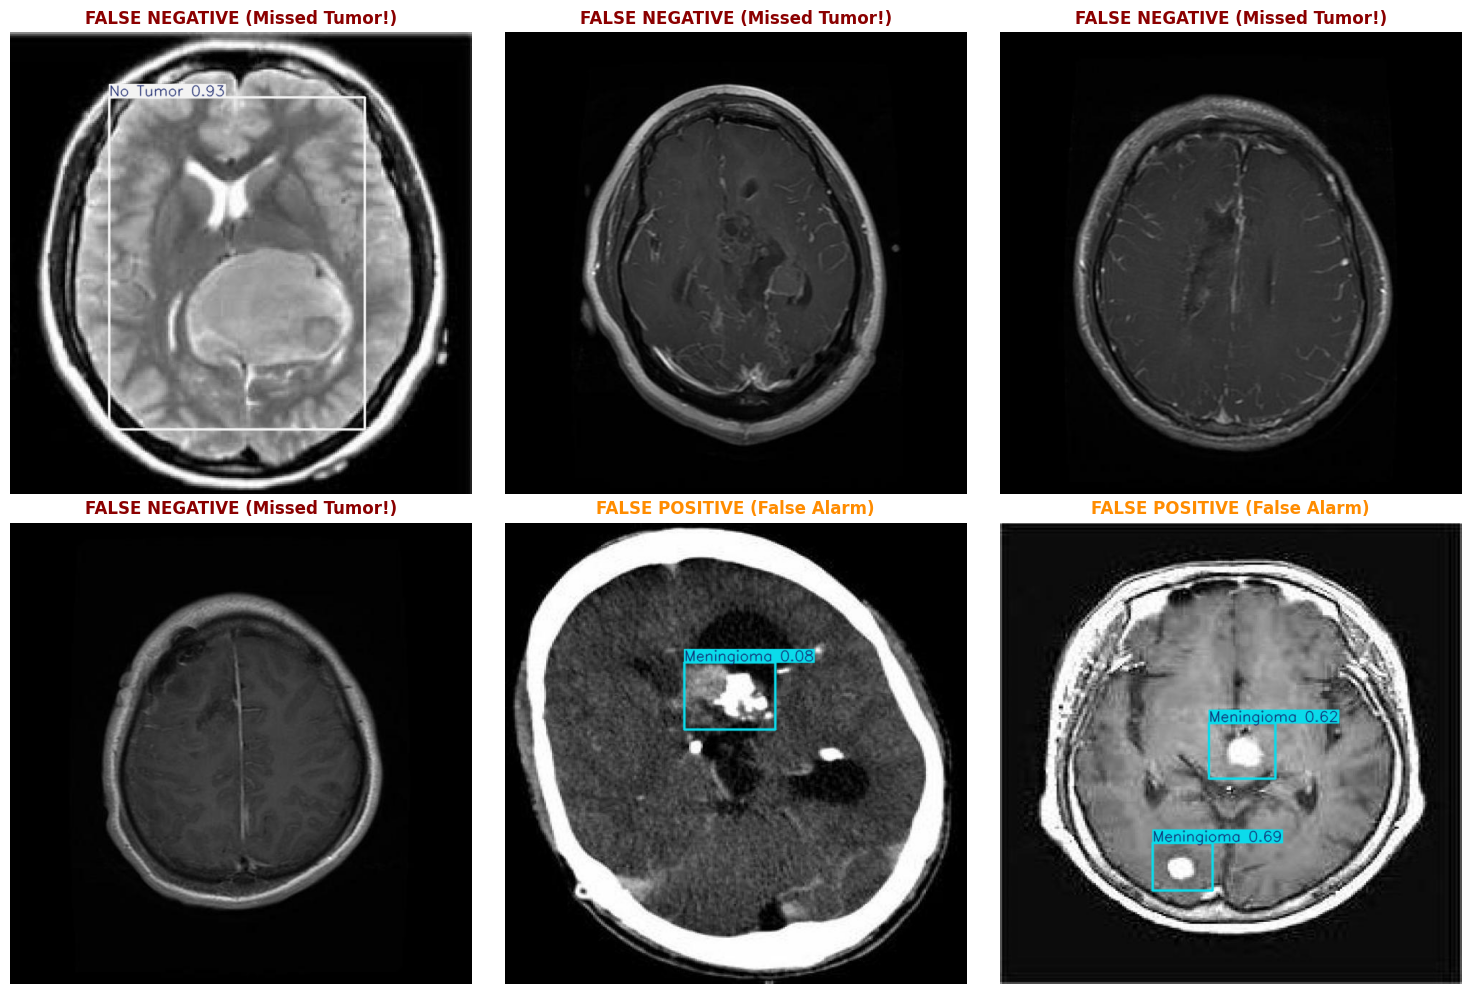

In [25]:
# Cell 7: Clinical Error Autopsy (Visualizing the 6 Mistakes)
import os
import glob
import matplotlib.pyplot as plt

print("Hunting down the exact False Negatives and False Positives...")

no_tumor_id = [id for id, name in model.names.items() if name.lower() == 'no tumor'][0]
test_img_dir = '../data/raw/test/images'
test_label_dir = '../data/raw/test/labels'
test_images = glob.glob(os.path.join(test_img_dir, '*.jpg'))

# Run predictions silently
results = model.predict(source=test_images, conf=0.05, verbose=False)

fn_cases = [] # Missed tumors
fp_cases = [] # False alarms

for original_img_path, r in zip(test_images, results):
    base_name = os.path.splitext(os.path.basename(original_img_path))[0]
    label_path = os.path.join(test_label_dir, f"{base_name}.txt")
    
    # 1. Was the patient actually sick?
    actual_sick = False
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            for line in f.readlines():
                if int(line.split()[0]) != no_tumor_id:
                    actual_sick = True
                    break

    # 2. Did the AI predict they were sick?
    pred_sick = False
    for box in r.boxes:
        if int(box.cls[0]) != no_tumor_id:
            pred_sick = True
            break
            
    # 3. Catch the mistakes!
    if actual_sick and not pred_sick:
        fn_cases.append(r) # Grab the YOLO result object
    elif not actual_sick and pred_sick:
        fp_cases.append(r)

# --- VISUALIZE THE MISTAKES ---
total_mistakes = len(fn_cases) + len(fp_cases)

if total_mistakes == 0:
    print("No mistakes found! The model is perfect.")
else:
    # Create a dynamic grid based on how many mistakes we found
    cols = 3
    rows = (total_mistakes + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = axes.flatten()
    
    # Combine the lists and keep track of what type of error they are
    all_mistakes = [("FALSE NEGATIVE (Missed Tumor!)", r, 'darkred') for r in fn_cases] + \
                   [("FALSE POSITIVE (False Alarm)", r, 'darkorange') for r in fp_cases]
    
    for i, (title, r, color) in enumerate(all_mistakes):
        # Draw the AI's prediction (even if it's empty)
        img_bgr = r.plot() 
        img_rgb = img_bgr[:, :, ::-1] 
        
        axes[i].imshow(img_rgb)
        axes[i].axis('off')
        axes[i].set_title(title, fontsize=12, fontweight='bold', color=color)
        
    # Hide any extra empty subplots
    for j in range(i + 1, len(axes)):
        axes[j].axis('off')
        
    plt.tight_layout()
    plt.show()